# The interaction-potential zoo

`jax_morph.physics.mechanics` ships a menu of effective cell-cell **pair potentials**, each a
`PairwisePotential` (so each gets `total_energy`, `forces`, per-cell `virial_pressure`, and works as
a drop-in for `MechanicalRelaxation` and `BrownianDynamics` for free). They fall into two families,
both sharing the contact distance `sigma = r_i + r_j`:

- **Purely repulsive, compact** (excluded volume, zero at and beyond contact):
  - **`SoftSphere`** - `(epsilon/2)(1 - r/sigma)^2`, the canonical soft-disk / active-matter model.
  - **`Hertzian`** - `(2/5) epsilon (1 - r/sigma)^(5/2)`, elastic-contact, a softer onset.
- **Adhesive** (a well at contact, cut at a size-relative range):
  - **`Morse`** - an exponential well.
  - **`Harmonic`** - a harmonic spring shifted to vanish at the cutoff (a negative well, minimum at
    contact): repulsive when squeezed, adhesive when stretched.
  - **`LennardJones`** - a hard `r^-12` core plus an `r^-6` adhesive tail, minimum `-epsilon` at
    contact.

We plot their energy and force signatures, show per-cell couplings, and contrast their dynamics.

In [1]:
import jax
import jax.numpy as jnp

# The library is written for float64; enable it before anything touches JAX.
jax.config.update('jax_enable_x64', True)

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

import jax_morph as jxm
from jax_morph.physics.mechanics import (
    Morse,
    SoftSphere,
    Hertzian,
    Harmonic,
    LennardJones,
    MechanicalRelaxation,
    BrownianDynamics,
)

print('jax-morph', jxm.__version__)

jax-morph 0.4.0


## 1. Energy and force signatures

For a single pair at contact distance `sigma = 1`, we evaluate each potential's `pair_energy(r)` and
its force `F(r) = -U'(r)` (repulsion positive) straight through `jax.grad`. We split the zoo by scale:
first the **hard-core adhesive** pair (Morse, Lennard-Jones), then the **soft** potentials
(SoftSphere, Hertzian, Harmonic). The green dotted line marks the contact distance `sigma`; the grey
dashed line marks the cutoff `2.5 sigma`, where Morse, Lennard-Jones, and Harmonic all end (the
compact repulsions vanish at `sigma` itself).

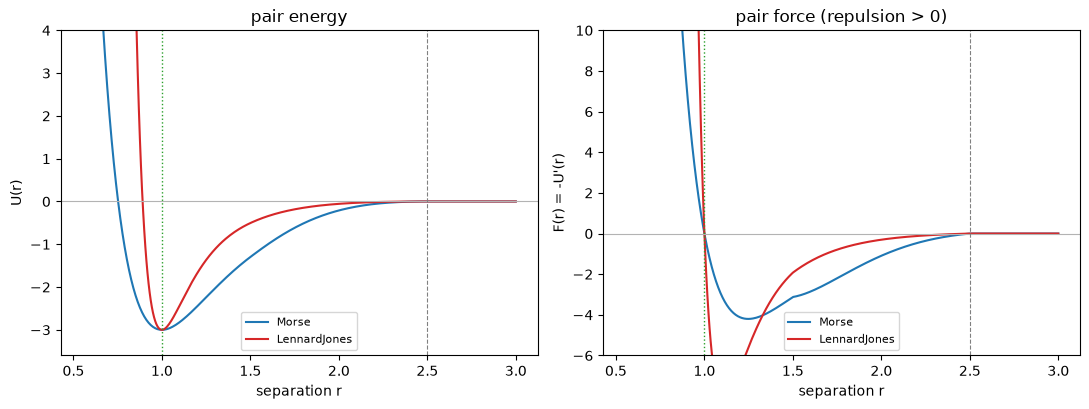

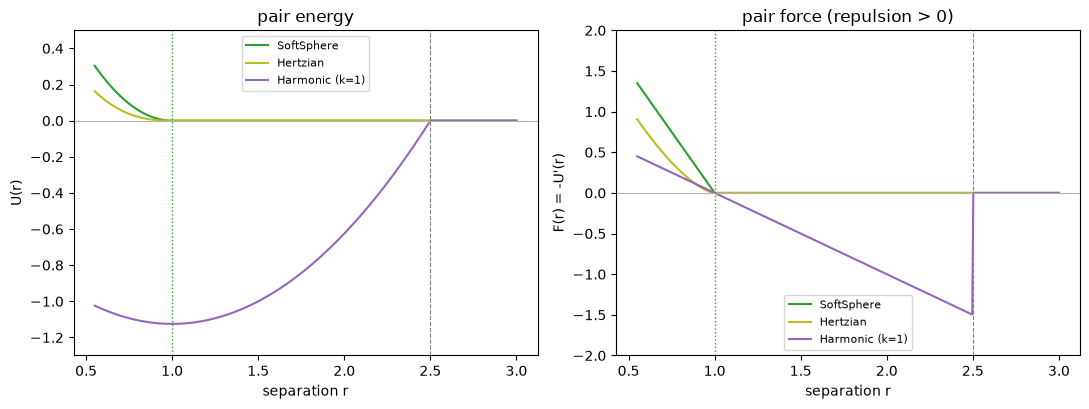

In [2]:
sigma = 1.0
r = jnp.linspace(0.55, 3.0, 400)


def plot_group(specs, energy_ylim, force_ylim):
    # each spec is (label, colour, potential, pair_params at sigma = 1) - signatures differ per potential.
    fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4.2))
    for label, color, pot, params in specs:
        U = jax.vmap(lambda rr: pot.pair_energy(rr, *params))(r)
        F = -jax.vmap(jax.grad(lambda rr: pot.pair_energy(rr, *params)))(r)
        a0.plot(r, U, color=color, label=label)
        a1.plot(r, F, color=color, label=label)
    for ax in (a0, a1):
        ax.axhline(0, color='0.7', lw=0.8)
        ax.axvline(sigma, color='tab:green', ls=':', lw=1)     # contact distance
        ax.axvline(2.5 * sigma, color='0.5', ls='--', lw=0.8)  # cutoff (2.5 sigma)
        ax.legend(fontsize=8)
    a0.set(xlabel='separation r', ylabel='U(r)', title='pair energy', ylim=energy_ylim)
    a1.set(xlabel='separation r', ylabel="F(r) = -U'(r)", title='pair force (repulsion > 0)', ylim=force_ylim)
    fig.tight_layout()
    plt.show()


# hard-core adhesive: deep wells and stiff cores
plot_group([
    ('Morse',        'tab:blue', Morse(), (sigma, 3.0, 2.8)),
    ('LennardJones', 'tab:red',  LennardJones(),   (sigma, 3.0)),
], energy_ylim=(-3.6, 4.0), force_ylim=(-6, 10))

# soft potentials: compact repulsion (SoftSphere, Hertzian) and the shifted spring (Harmonic).
# Harmonic is shown at k = 1 (vs epsilon = 3 for the repulsive pair) so all three share a scale.
plot_group([
    ('SoftSphere',   'tab:green',  SoftSphere(), (sigma, 3.0)),
    ('Hertzian',     'tab:olive',  Hertzian(),   (sigma, 3.0)),
    ('Harmonic (k=1)', 'tab:purple', Harmonic(), (sigma, 1.0)),
], energy_ylim=(-1.3, 0.5), force_ylim=(-2.0, 2.0))

Read them off. **Hard core (top):** `Morse` and `LennardJones` both dip to a negative well at `sigma`
(adhesion) and switch off past the cutoff, with `LennardJones` by far the stiffest repulsive core.
**Soft (bottom):** `SoftSphere`/`Hertzian` are positive-only and vanish exactly at `sigma` (compact
excluded volume, no attractive tail), Hertzian with the gentler onset; `Harmonic` is a harmonic
spring **shifted** so it vanishes at the cutoff - a negative well whose clean linear restoring force
is attractive when stretched, then exactly 0 (and energy 0) past the cutoff.

## 2. Couplings: shared scalar or per-cell state field

Every coupling (`epsilon`, `k`) is either a **shared scalar** (a Python float is frozen; a
`jax.Array` is traced and optimizable) or a **per-cell** value read from a state field: pass a
`StateFieldSpec` and each pair's coupling is the arithmetic mean of the two cells' values. There is no
separate per-type matrix - a **type-dependent** interaction is just a per-cell coupling written from
`celltype` (by a fixed initial condition here, or an upstream controller in a full model). The owning
step surfaces the potential's read, so `build_state_from_model` allocates the field.

In [3]:
adhesion = jxm.StateFieldSpec('adhesion')          # a per-cell field the potential reads epsilon from
pot = Morse(epsilon=adhesion)
model = jxm.Model([MechanicalRelaxation(pot, max_steps=1, f_tol=1e-6)])
State = jxm.build_state_from_model(model)           # the synthesized schema now carries `adhesion`

eps_by_type = jnp.array([1.0, 5.0])                 # type 0 weakly adhesive, type 1 strongly adhesive
types = jnp.array([0, 0, 1, 1])
s = State.init_empty(capacity=4, n_space_dim=2, n_types=2)
s = s.update(
    alive=s.alive.at[:].set(True),
    radius=s.radius.at[:].set(0.5),
    celltype=jax.nn.one_hot(types, 2),
    adhesion=eps_by_type[types],                    # per-cell epsilon written from the cell type
)

print('per-cell adhesion (epsilon):', np.asarray(s.adhesion))
print('the potential surfaces its read:', [sp.name for sp in pot.state_reads()])
print('per-pair well depths eps_ij = mix(adhesion):')
print(np.asarray(pot.mix(s.adhesion)))
print('-> a 0-1 pair feels (1 + 5) / 2 = 3, between the 0-0 (=1) and 1-1 (=5) wells')

per-cell adhesion (epsilon): [1. 1. 5. 5.]
the potential surfaces its read: ['adhesion']
per-pair well depths eps_ij = mix(adhesion):
[[1. 1. 3. 3.]
 [1. 1. 3. 3.]
 [3. 3. 5. 5.]
 [3. 3. 5. 5.]]
-> a 0-1 pair feels (1 + 5) / 2 = 3, between the 0-0 (=1) and 1-1 (=5) wells


## 3. Dynamics: repulsive spreads, adhesive condenses

The potentials are drop-ins for `BrownianDynamics`. Starting from the **same** noisy lattice - cells
placed on a grid with a small random jitter, spaced so no two overlap (every separation stays above
the contact distance `sigma`) - a cold overdamped rollout under the purely repulsive `SoftSphere`
lets thermal motion **spread** the cells (nothing binds them; excluded volume only keeps them from
re-stacking), while the adhesive `Morse` well pulls each neighbour to contact and **condenses** the
cloud into a compact packed blob. Seeding from a non-overlapping lattice (with a small `dt`) is what
keeps `Morse` well-behaved: its repulsive core is numerically stiff for the explicit Euler-Maruyama
step, so a cold start that never drives a pair deep into that core avoids the blow-ups a compact
overlapping cloud would trigger.

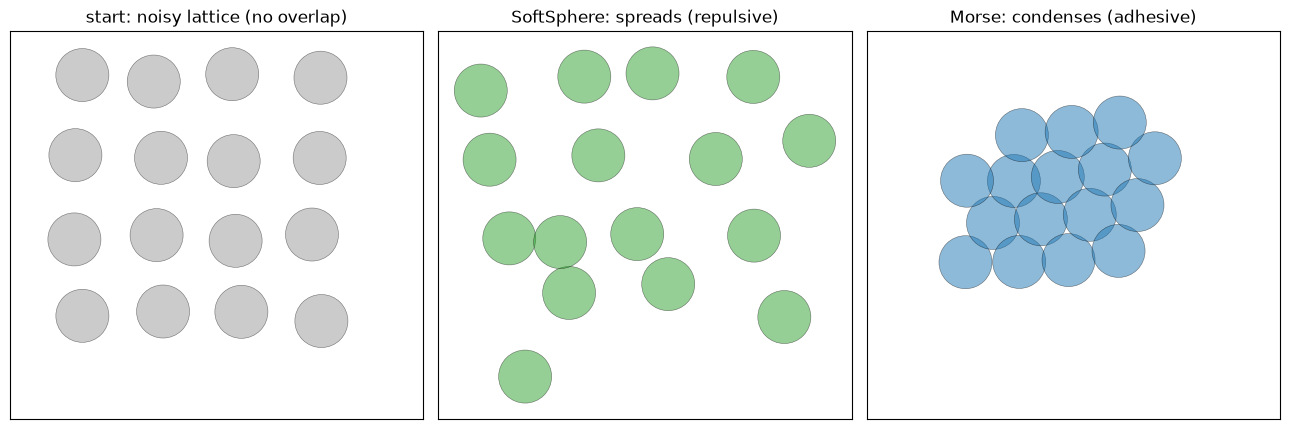

mean pairwise distance:  start 3.21  ->  SoftSphere 3.52 (spread)  |  Morse 1.86 (condensed)


In [4]:
# a noisy square lattice: cells on a grid with a small jitter, spaced so none overlap (sep > sigma = 1)
n_side, spacing, jitter = 4, 1.5, 0.12
n = n_side * n_side
axis = (jnp.arange(n_side) - (n_side - 1) / 2) * spacing
gx, gy = jnp.meshgrid(axis, axis, indexing='ij')
lattice = jnp.stack([gx.ravel(), gy.ravel()], axis=-1)
start = lattice + jax.random.uniform(jax.random.PRNGKey(3), lattice.shape, minval=-jitter, maxval=jitter)


def rollout(pot):
    model = jxm.Model([BrownianDynamics(pot, n_space_dim=2, gamma=1.0, kT=0.02)])
    s0 = jxm.build_state_from_model(model).init_empty(capacity=n, n_space_dim=2, n_types=1)
    s0 = s0.update(alive=s0.alive.at[:].set(True), radius=s0.radius.at[:].set(0.5),
                   position=s0.position.at[:].set(start))
    sT = jxm.simulate(model, s0, n_steps=1200, dt=0.005, key=jax.random.PRNGKey(8))
    return s0, sT


s0, s_rep = rollout(SoftSphere(epsilon=3.0))
_, s_adh = rollout(Morse(epsilon=1.0, alpha=2.8))

# a shared, generous frame from the most-spread panel so the contrast is visible
allpos = np.concatenate([np.asarray(s.position) for s in (s0, s_rep, s_adh)])
pad = 0.8
xlim = (allpos[:, 0].min() - pad, allpos[:, 0].max() + pad)
ylim = (allpos[:, 1].min() - pad, allpos[:, 1].max() + pad)

fig, (a0, a1, a2) = plt.subplots(1, 3, figsize=(13, 4.6))
jxm.viz.draw(s0, ax=a0, color='0.6', alpha=0.5, lims=(xlim, ylim),
             title='start: noisy lattice (no overlap)')
jxm.viz.draw(s_rep, ax=a1, color='tab:green', alpha=0.5, lims=(xlim, ylim),
             title='SoftSphere: spreads (repulsive)')
jxm.viz.draw(s_adh, ax=a2, color='tab:blue', alpha=0.5, lims=(xlim, ylim),
             title='Morse: condenses (adhesive)')
fig.tight_layout()
plt.show()


def mean_pair_distance(s):
    p = np.asarray(s.position)
    iu = np.triu_indices(len(p), 1)
    return float(np.linalg.norm(p[:, None] - p[None], axis=-1)[iu].mean())


print(f'mean pairwise distance:  start {mean_pair_distance(s0):.2f}'
      f'  ->  SoftSphere {mean_pair_distance(s_rep):.2f} (spread)'
      f'  |  Morse {mean_pair_distance(s_adh):.2f} (condensed)')